# Basic Usage

In [3]:
import operator
from typing import TypedDict, Annotated

from langgraph.graph import StateGraph


class OverallState(TypedDict):
    logs: Annotated[list[str], operator.add]
    step_id: str


def node_01(state: OverallState) -> OverallState:
    step_id = state.get("step_id", "")
    return {
        "logs": ["node_01 executed!"],
        "step_id": step_id + ", node_01"
    }


def node_02(state: OverallState) -> OverallState:
    step_id = state.get("step_id", "")
    return {
        "logs": ["node_02 executed!"],
        "step_id": step_id + ", node_02"
    }


build = StateGraph(state_schema=OverallState)
build.add_node(node="node_01", action=node_01)
build.add_node(node="node_02", action=node_02)
build.add_edge("node_01", "node_02")
build.add_edge("node_02", END)
build.set_entry_point("node_01")

graph = build.compile()

result = graph.invoke({
    "step_id": "start",
})

print(result)

{'logs': ['node_01 executed!', 'node_02 executed!'], 'step_id': 'start, node_01, node_02'}


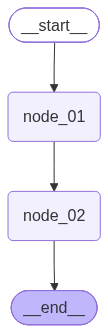

In [4]:
display(graph)

## Three type of custom agent state

### TypedDict

Refer to above code

### @dataclass

In [5]:
from dataclasses import dataclass


@dataclass
class OverallState:
    logs: Annotated[list[str], operator.add]
    step_id: str


def node_01(state: OverallState) -> OverallState:
    step_id = state.step_id
    return {
        "logs": ["node_01 executed!"],
        "step_id": step_id + ", node_01"
    }


def node_02(state: OverallState) -> OverallState:
    step_id = state.step_id
    return OverallState(logs=["node_02 executed!"], step_id=step_id + ", node_02")


build = StateGraph(state_schema=OverallState)
build.add_node(node="node_01", action=node_01)
build.add_node(node="node_02", action=node_02)
build.add_edge("node_01", "node_02")
build.add_edge("node_02", END)
build.set_entry_point("node_01")

graph = build.compile()

result = graph.invoke({
    "step_id": "start",
})

print(result)

{'logs': ['node_01 executed!', 'node_02 executed!'], 'step_id': 'start, node_01, node_02'}


### Pydantic

In [11]:

from pydantic import BaseModel


class OverallState(BaseModel):
    logs: Annotated[list[str], operator.add]
    step_id: str


def node_01(state: OverallState) -> OverallState:
    step_id = state.step_id
    return {
        "logs": ["node_01 executed!"],
        "step_id": step_id + ", node_01"
    }


def node_02(state: OverallState) -> OverallState:
    step_id = state.step_id
    return {
        # "logs": ["node_01 executed!"],
        "step_id": step_id + ", node_02"
    }


build = StateGraph(state_schema=OverallState)
build.add_node(node="node_01", action=node_01)
build.add_node(node="node_02", action=node_02)
build.add_edge("node_01", "node_02")
build.add_edge("node_02", END)
build.set_entry_point("node_01")

graph = build.compile()

result = graph.invoke({
    "step_id": "start",
})

print(result)

{'logs': ['node_01 executed!'], 'step_id': 'start, node_01, node_02'}


## Reducer

### Custom Reducer

In [16]:
def custom_reducer(left: list[str], right: list[str]) -> list[str]:
    return left + right


class CustomState(TypedDict):
    logs: Annotated[list[str], custom_reducer]


def node_01(state: CustomState) -> CustomState:
    return {
        "logs": ["node_01 executed!"],
    }


def node_02(state: CustomState) -> CustomState:
    return {
        "logs": ["node_02 executed!"],
    }


build = StateGraph(state_schema=CustomState)
build.add_node(node="node_01", action=node_01)
build.add_node(node="node_02", action=node_02)
build.add_edge("node_01", "node_02")
build.add_edge("node_02", END)
build.set_entry_point("node_01")

graph = build.compile()

result = graph.invoke({})
print(result)

{'logs': ['node_01 executed!', 'node_02 executed!']}


### Built-in default messages reducer

- If a message with the same ID already exists in the message list on the left, the existing message will be replaced with the new one, regardless of the existing message’s type.
- Otherwise, the new message will be appended to the end of the list.

In [19]:
from langgraph.graph import add_messages
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from rich import print as rprint

left = [
    SystemMessage(content="你是个善解人意的助手", id='1'),
    HumanMessage(content="你好", id='2'),
    AIMessage(content="你好~", id='3'),
]

right = [
    HumanMessage(content="我是老王，你是小王", id='2'),
    AIMessage(content="好的，我记住啦", id='3'),
    HumanMessage(content="你是谁？", id='4'),
    AIMessage(content="我是小王", id='5'),
]

merge = add_messages(left=left, right=right)
rprint(merge)

[
    SystemMessage(content='你是个善解人意的助手', additional_kwargs={}, response_metadata={}, id='1'),
    HumanMessage(content='我是老王，你是小王', additional_kwargs={}, response_metadata={}, id='2'),
    AIMessage(
        content='好的，我记住啦',
        additional_kwargs={},
        response_metadata={},
        id='3',
        tool_calls=[],
        invalid_tool_calls=[]
    ),
    HumanMessage(content='你是谁？', additional_kwargs={}, response_metadata={}, id='4'),
    AIMessage(
        content='我是小王',
        additional_kwargs={},
        response_metadata={},
        id='5',
        tool_calls=[],
        invalid_tool_calls=[]
    )
]

## State

- `state` represents the global state snapshot when the current node is called, and several downstream nodes receive the same snapshot.

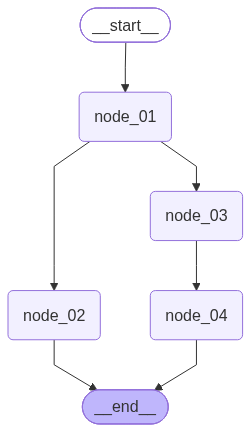

item: ('logs', [])
item: ('logs', ['node_01 executed!'])
item: ('logs', ['node_01 executed!'])
item: ('logs', ['node_01 executed!', 'node_02 executed!', 'node_03 executed!'])
{'logs': ['node_01 executed!', 'node_02 executed!', 'node_03 executed!', 'node_04 executed!']}


In [25]:

from operator import add


class CustomState(TypedDict):
    logs: Annotated[list[str], add]


def node_01(state: CustomState) -> CustomState:
    for item in state.items():
        print(f"item: {item}")

    return {
        "logs": ["node_01 executed!"],
    }


def node_02(state: CustomState) -> CustomState:
    for item in state.items():
        print(f"item: {item}")

    return {
        "logs": ["node_02 executed!"],
    }


def node_03(state: CustomState) -> CustomState:
    time.sleep(2)
    for item in state.items():
        print(f"item: {item}")

    return {
        "logs": ["node_03 executed!"],
    }


def node_04(state: CustomState) -> CustomState:
    for item in state.items():
        print(f"item: {item}")

    return {
        "logs": ["node_04 executed!"],
    }


build = StateGraph(state_schema=CustomState)
build.add_node(node="node_01", action=node_01)
build.add_node(node="node_02", action=node_02)
build.add_node(node="node_03", action=node_03)
build.add_node(node="node_04", action=node_04)
build.add_edge("node_01", "node_02")
build.add_edge("node_01", "node_03")
build.add_edge("node_03", "node_04")
build.set_entry_point("node_01")
build.set_finish_point("node_04")

graph = build.compile()
display(graph)
result = graph.invoke({})
print(result)

### Update & Overwrite

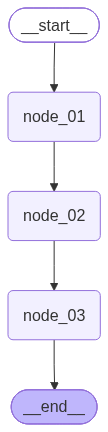

{'logs': ['node_02 executed!', 'node_03 executed!']}


In [31]:
from langgraph.types import Overwrite


class CustomState(TypedDict):
    logs: Annotated[list[str], operator.add]


def node_01(state: CustomState) -> CustomState:
    return {
        "logs": ["node_01 executed!"],
    }


def node_02(state: CustomState) -> CustomState:
    return {
        "logs": Overwrite(["node_02 executed!"])
    }


def node_03(state: CustomState) -> CustomState:
    return {
        "logs": ["node_03 executed!"],
    }


build = StateGraph(state_schema=CustomState)
build.add_node(node="node_01", action=node_01)
build.add_node(node="node_02", action=node_02)
build.add_node(node="node_03", action=node_03)
build.add_edge("node_01", "node_02")
build.add_edge("node_02", "node_03")
build.set_entry_point("node_01")
build.set_finish_point("node_03")

graph = build.compile()
display(graph)

result = graph.invoke({"logs": ["start"]})
print(result)

### Update state value without reducer in parallel

- Multiple nodes cannot update the same state key concurrently unless a reducer is defined for that key.


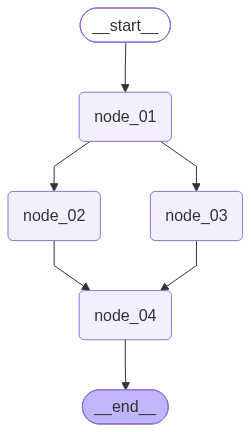

node1 start...
item: ('logs', [])
node3 start...
item: ('logs', ['node_01 executed!'])
node2 start...
item: ('logs', ['node_01 executed!'])


InvalidUpdateError: At key 'id': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE

In [42]:
from langgraph.constants import END
from operator import add
import time


class CustomState(TypedDict):
    logs: Annotated[list[str], add]
    id: str


def node_01(state: CustomState) -> CustomState:
    print("node1 start...")
    for item in state.items():
        print(f"item: {item}")

    return {
        "logs": ["node_01 executed!"],
    }


def node_02(state: CustomState) -> CustomState:
    time.sleep(2)
    print("node2 start...")
    for item in state.items():
        print(f"item: {item}")

    return {
        "logs": ["node_02 executed!"],
        "id": "2"
    }


def node_03(state: CustomState) -> CustomState:
    print("node3 start...")
    for item in state.items():
        print(f"item: {item}")

    return {
        "logs": ["node_03 executed!"],
        "id": "3"
    }


def node_04(state: CustomState) -> CustomState | None:
    print("node4 start...")
    return None


build = StateGraph(state_schema=CustomState)
build.add_node(node="node_01", action=node_01)
build.add_node(node="node_02", action=node_02)
build.add_node(node="node_03", action=node_03)
build.add_node(node="node_04", action=node_04)
build.add_edge("node_01", "node_02")
build.add_edge("node_01", "node_03")
build.add_edge("node_03", "node_04")
build.add_edge("node_02", "node_04")
build.add_edge("node_04", END)
build.set_entry_point("node_01")

graph = build.compile()
display(graph)
result = graph.invoke({})
print(f"\n{result=}")

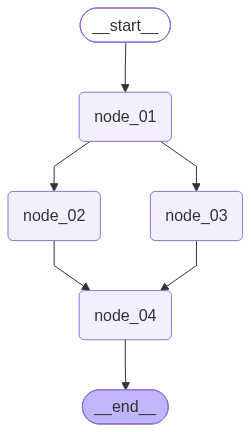

node1 start...
item: ('logs', [])
item: ('id', '')
node3 start...
item: ('logs', ['node_01 executed!'])
item: ('id', '')
node2 start...
item: ('logs', ['node_01 executed!'])
item: ('id', '')
node4 start...

result={'logs': ['node_01 executed!', 'node_02 executed!', 'node_03 executed!'], 'id': '23'}


In [43]:
class CustomState(TypedDict):
    logs: Annotated[list[str], add]
    id: Annotated[str, add]


build = StateGraph(state_schema=CustomState)
build.add_node(node="node_01", action=node_01)
build.add_node(node="node_02", action=node_02)
build.add_node(node="node_03", action=node_03)
build.add_node(node="node_04", action=node_04)
build.add_edge("node_01", "node_02")
build.add_edge("node_01", "node_03")
build.add_edge("node_03", "node_04")
build.add_edge("node_02", "node_04")
build.add_edge("node_04", END)
build.set_entry_point("node_01")

graph = build.compile()
display(graph)
result = graph.invoke({})
print(f"\n{result=}")

### state_schema & input_schema & output_schema & private_schema

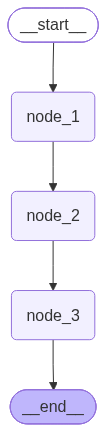

test
{'graph_output': 'Dear 小黄, 早上好~ 很高兴认识你！'}


In [57]:

from langgraph.constants import END, START


class InputState(TypedDict):
    username: str


class OutputState(TypedDict):
    graph_output: str


class OverAllState(TypedDict):
    nickname: str
    username: str
    graph_output: str


class PrivateState(TypedDict):
    greeting: str


class Node3State(OverAllState, PrivateState):
    pass


class Node2Update(PrivateState, OutputState):
    pass


def node_1(state: InputState) -> OverAllState:
    # 向全局状态写入数据
    return {
        "nickname": "Dear " + state["username"]
    }


def node_2(state: OverAllState) -> Node2Update:
    # 从全局状态读取数据，写入私有状态
    return {
        "greeting": state["nickname"] + ", 早上好~",
        "graph_output": "test"
    }


def node_3(state: Node3State) -> OutputState:
    print(state.get("graph_output"))
    # 从私有状态读取数据，写入输出状态
    return {
        "graph_output": state["greeting"] + " 很高兴认识你！"
    }


builder = StateGraph(OverAllState, input_schema=InputState, output_schema=OutputState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

graph = builder.compile()

display(graph)
print(graph.invoke({"username": "小黄"}))

### Preset state

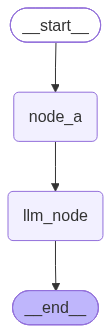

llm_response=AIMessage(content='Hello! 😊 How can I help you today?', additional_kwargs={'refusal': None, 
'reasoning_content': 'We need answer to user. They said "Hello, World!" likely greeting. Need respond friendly. 
Maybe mention hello. Keep concise.'}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 
87, 'total_tokens': 126, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 
'reasoning_tokens': 27, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 
'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 87}, 'model_provider': 'deepseek', 
'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': 
'40525858-750f-4bd8-8550-3e8585aa724a', 'finish_reason': 'stop', 'logprobs': None}, 
id='lc_run--019ff4b7-151e-7f40-b52e-996b9748cd81-0', tool_calls=[], invalid_tool_calls=[], 
usage_metadata={'input_tokens': 87, 'output_tokens': 39, 'total_tokens': 126, 'input_token_details': {'cache_read':
0}, 'output_token_details': {'reasoning': 27}})

{
    'messages': [
        HumanMessage(
            content='Hello, World!',
            additional_kwargs={},
            response_metadata={},
            id='e9926ffb-d13f-4c93-8f8c-f42843bd9e9a'
        ),
        AIMessage(
            content='Hello! 😊 How can I help you today?',
            additional_kwargs={
                'refusal': None,
                'reasoning_content': 'We need answer to user. They said "Hello, World!" likely greeting. Need 
respond friendly. Maybe mention hello. Keep concise.'
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 39,
                    'prompt_tokens': 87,
                    'total_tokens': 126,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 27,
                        'rejected_prediction_tokens': None
                    },
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 87
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402',
                'id': '40525858-750f-4bd8-8550-3e8585aa724a',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019ff4b7-151e-7f40-b52e-996b9748cd81-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 87,
                'output_tokens': 39,
                'total_tokens': 126,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 27}
            }
        )
    ],
    'username': 'DeltaV',
    'output': 'Hello! 😊 How can I help you today?'
}

In [62]:
from langgraph.graph import MessagesState
from dotenv import load_dotenv

from langchain.chat_models import init_chat_model

load_dotenv(override=True)

model = init_chat_model(model="deepseek:deepseek-v4-flash")


class OverAllState(MessagesState):
    username: str
    output: str


def node_a(state: OverAllState) -> OverAllState:
    return {
        "messages": [HumanMessage(content="Hello, World!")]
    }


def llm_node(state: OverAllState) -> OverAllState:
    llm_response = model.invoke(state["messages"])
    rprint(f"{llm_response=}")
    return {
        "messages": [llm_response],
        "output": llm_response.content
    }


builder = StateGraph(OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("llm_node", llm_node)
builder.add_edge("node_a", "llm_node")
builder.set_entry_point("node_a")
builder.set_finish_point("llm_node")

graph = builder.compile()
display(graph)

response = graph.invoke({"username": "DeltaV"})
rprint(response)